# PlantVillage Dataset Exploration
## Plant Disease Detection - 15 Classes

This notebook explores the PlantVillage dataset for training a YOLOv8 classification model.

**Expected Classes: 15**
- Peppers: 2 classes
- Potatoes: 3 classes
- Tomatoes: 10 classes

In [1]:
# Cell 1: Setup and imports
from pathlib import Path
import matplotlib.pyplot as plt
from PIL import Image
import random
import numpy as np
from collections import Counter

# Set style for better plots
plt.style.use('seaborn-v0_8-darkgrid')

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Cell 2: Load PlantVillage dataset with verification
dataset_path = Path("datasets/plantvillage/train/PlantVillage")

# Expected 15 classes
EXPECTED_CLASSES = [
    'Pepper__bell___Bacterial_spot',
    'Pepper__bell___healthy',
    'Potato___Early_blight',
    'Potato___Late_blight',
    'Potato___healthy',
    'Tomato_Bacterial_spot',
    'Tomato_Early_blight',
    'Tomato_Late_blight',
    'Tomato_Leaf_Mold',
    'Tomato_Septoria_leaf_spot',
    'Tomato_Spider_mites_Two_spotted_spider_mite',
    'Tomato__Target_Spot',
    'Tomato__Tomato_YellowLeaf__Curl_Virus',
    'Tomato__Tomato_mosaic_virus',
    'Tomato_healthy'
]

# Check if dataset exists
if dataset_path.exists():
    print("Dataset found!\n")
    
    # Get all class folders
    classes = sorted([d.name for d in dataset_path.iterdir() if d.is_dir()])
    
    print("=" * 70)
    print(f"DATASET VERIFICATION")
    print("=" * 70)
    print(f"Found: {len(classes)} folders")
    print(f"Expected: {len(EXPECTED_CLASSES)} classes\n")
    
    # Verify classes
    missing_classes = []
    extra_classes = []
    
    for expected in EXPECTED_CLASSES:
        if expected not in classes:
            missing_classes.append(expected)
    
    for found in classes:
        if found not in EXPECTED_CLASSES:
            extra_classes.append(found)
    
    if missing_classes:
        print("WARNING - MISSING CLASSES:")
        for cls in missing_classes:
            print(f"   - {cls}")
        print()
    
    if extra_classes:
        print("WARNING - EXTRA/UNEXPECTED FOLDERS (SHOULD BE REMOVED):")
        for cls in extra_classes:
            print(f"   - {cls}")
        print()
        print("NOTE: These folders will cause issues during training!")
        print("      Please remove them before proceeding.\n")
    
    if not missing_classes and not extra_classes:
        print("SUCCESS: All 15 expected classes found.\n")
    
    print("=" * 70)
    print("\nAll folders in dataset:")
    for i, cls in enumerate(classes, 1):
        status = "[OK]" if cls in EXPECTED_CLASSES else "[!!]"  
        print(f"  {i:2d}. {status} {cls}")
        
else:
    print("ERROR: Dataset not found!")
    print(f"Please ensure the dataset is located at: {dataset_path}")
    print("\nDownload from: https://www.kaggle.com/datasets/emmarex/plantdisease")

Dataset found!

DATASET VERIFICATION
Found: 15 folders
Expected: 15 classes

SUCCESS: All 15 expected classes found.


All folders in dataset:
   1. [OK] Pepper__bell___Bacterial_spot
   2. [OK] Pepper__bell___healthy
   3. [OK] Potato___Early_blight
   4. [OK] Potato___Late_blight
   5. [OK] Potato___healthy
   6. [OK] Tomato_Bacterial_spot
   7. [OK] Tomato_Early_blight
   8. [OK] Tomato_Late_blight
   9. [OK] Tomato_Leaf_Mold
  10. [OK] Tomato_Septoria_leaf_spot
  11. [OK] Tomato_Spider_mites_Two_spotted_spider_mite
  12. [OK] Tomato__Target_Spot
  13. [OK] Tomato__Tomato_YellowLeaf__Curl_Virus
  14. [OK] Tomato__Tomato_mosaic_virus
  15. [OK] Tomato_healthy


In [3]:
# Cell 3: Count images per class
print("\n" + "=" * 70)
print("IMAGE COUNT PER CLASS")
print("=" * 70)

class_counts = {}
total_images = 0

# Group by plant type
pepper_classes = []
potato_classes = []
tomato_classes = []

for cls in classes:
    if cls in EXPECTED_CLASSES:  # Only count expected classes
        class_path = dataset_path / cls
        images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.JPG'))
        count = len(images)
        class_counts[cls] = count
        total_images += count
        
        # Categorize by plant type
        if cls.startswith('Pepper'):
            pepper_classes.append((cls, count))
        elif cls.startswith('Potato'):
            potato_classes.append((cls, count))
        elif cls.startswith('Tomato'):
            tomato_classes.append((cls, count))

# Display by plant type
print("\nPEPPERS (2 classes):")
print("-" * 70)
for cls, count in pepper_classes:
    disease = cls.replace('Pepper__bell___', '')
    print(f"  {disease:40s} {count:>6,} images")
pepper_total = sum(c for _, c in pepper_classes)
print(f"  {'Peppers Subtotal':40s} {pepper_total:>6,} images")

print("\nPOTATOES (3 classes):")
print("-" * 70)
for cls, count in potato_classes:
    disease = cls.replace('Potato___', '')
    print(f"  {disease:40s} {count:>6,} images")
potato_total = sum(c for _, c in potato_classes)
print(f"  {'Potatoes Subtotal':40s} {potato_total:>6,} images")

print("\nTOMATOES (10 classes):")
print("-" * 70)
for cls, count in tomato_classes:
    disease = cls.replace('Tomato_', '').replace('Tomato__', '')
    print(f"  {disease:40s} {count:>6,} images")
tomato_total = sum(c for _, c in tomato_classes)
print(f"  {'Tomatoes Subtotal':40s} {tomato_total:>6,} images")

print("\n" + "=" * 70)
print(f"{'TOTAL (15 classes)':40s} {total_images:>6,} images")
print("=" * 70)


IMAGE COUNT PER CLASS

PEPPERS (2 classes):
----------------------------------------------------------------------
  Bacterial_spot                            1,994 images
  healthy                                   2,954 images
  Peppers Subtotal                          4,948 images

POTATOES (3 classes):
----------------------------------------------------------------------
  Early_blight                              2,000 images
  Late_blight                               2,000 images
  healthy                                     304 images
  Potatoes Subtotal                         4,304 images

TOMATOES (10 classes):
----------------------------------------------------------------------
  Bacterial_spot                            4,254 images
  Early_blight                              2,000 images
  Late_blight                               3,816 images
  Leaf_Mold                                 1,904 images
  Septoria_leaf_spot                        3,542 images
  Spider_mi

In [4]:
# Cell 4: Dataset statistics
print("\n" + "=" * 70)
print("DATASET STATISTICS")
print("=" * 70)

counts = list(class_counts.values())

print(f"\nTotal Images:    {total_images:>8,}")
print(f"Total Classes:   {len(class_counts):>8}")
print(f"\nAverage/Class:   {np.mean(counts):>8,.0f} images")
print(f"Median/Class:    {np.median(counts):>8,.0f} images")
print(f"Min/Class:       {np.min(counts):>8,} images")
print(f"Max/Class:       {np.max(counts):>8,} images")
print(f"Std Dev:         {np.std(counts):>8,.0f} images")

# Check for class imbalance
print("\n" + "=" * 70)
print("CLASS IMBALANCE ANALYSIS")
print("=" * 70)

min_count = np.min(counts)
max_count = np.max(counts)
imbalance_ratio = max_count / min_count

print(f"\nImbalance Ratio: {imbalance_ratio:.2f}x")
print(f"(Largest class / Smallest class)\n")

if imbalance_ratio > 3.0:
    print("WARNING: SEVERE IMBALANCE - Consider using weighted loss or oversampling")
elif imbalance_ratio > 2.0:
    print("WARNING: MODERATE IMBALANCE - Model may favor larger classes")
else:
    print("STATUS: BALANCED - Classes are relatively well-balanced")

# Show top 3 largest and smallest classes
sorted_classes = sorted(class_counts.items(), key=lambda x: x[1], reverse=True)

print("\nLargest 3 classes:")
for cls, count in sorted_classes[:3]:
    percentage = (count / total_images) * 100
    print(f"  {cls:50s} {count:>6,} ({percentage:5.2f}%)")

print("\nSmallest 3 classes:")
for cls, count in sorted_classes[-3:]:
    percentage = (count / total_images) * 100
    print(f"  {cls:50s} {count:>6,} ({percentage:5.2f}%)")


DATASET STATISTICS

Total Images:      41,272
Total Classes:         15

Average/Class:      2,751 images
Median/Class:       2,808 images
Min/Class:            304 images
Max/Class:          6,416 images
Std Dev:            1,438 images

CLASS IMBALANCE ANALYSIS

Imbalance Ratio: 21.11x
(Largest class / Smallest class)


Largest 3 classes:
  Tomato__Tomato_YellowLeaf__Curl_Virus               6,416 (15.55%)
  Tomato_Bacterial_spot                               4,254 (10.31%)
  Tomato_Late_blight                                  3,816 ( 9.25%)

Smallest 3 classes:
  Tomato_Leaf_Mold                                    1,904 ( 4.61%)
  Tomato__Tomato_mosaic_virus                           746 ( 1.81%)
  Potato___healthy                                      304 ( 0.74%)


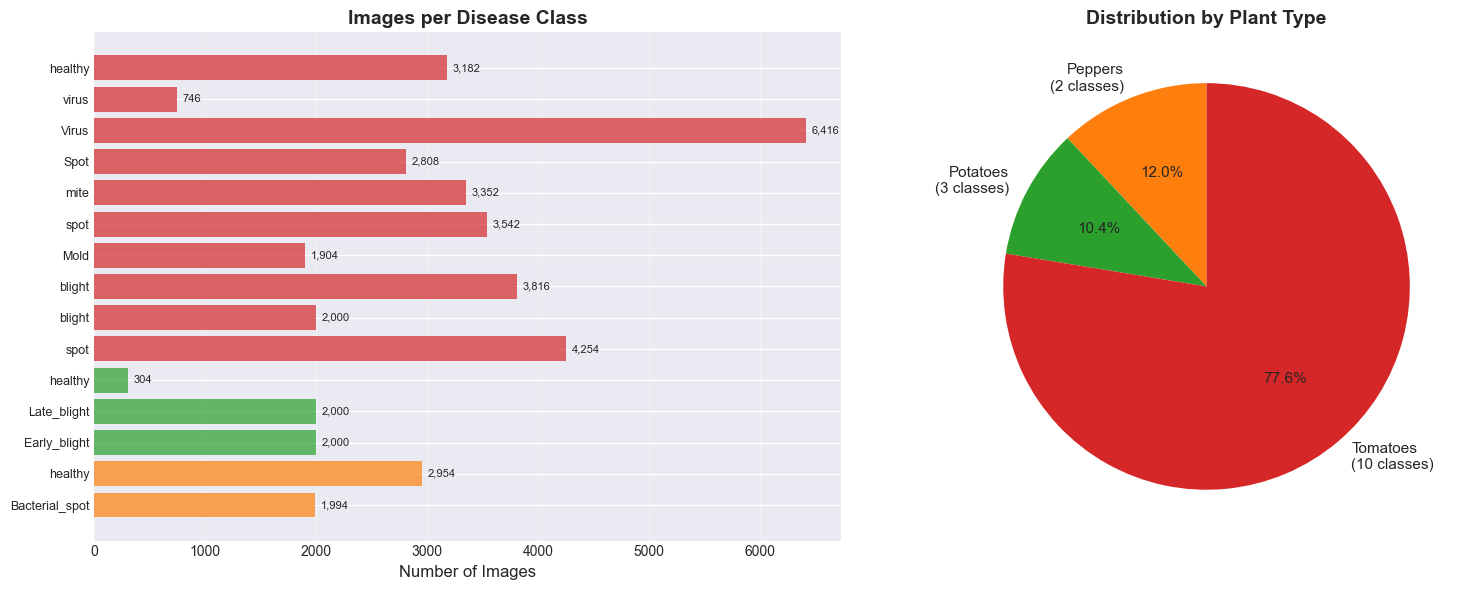

Chart saved as 'visualizations/dataset_distribution.png'


In [5]:
# Cell 5: Visualize class distribution
# Create visualizations directory if it doesn't exist
Path('visualizations').mkdir(exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart of all classes
classes_list = list(class_counts.keys())
counts_list = list(class_counts.values())

# Shorten class names for display
short_names = [cls.split('___')[-1] if '___' in cls else cls.split('_')[-1] for cls in classes_list]

colors = ['#ff7f0e' if cls.startswith('Pepper') else '#2ca02c' if cls.startswith('Potato') else '#d62728' for cls in classes_list]

axes[0].barh(range(len(classes_list)), counts_list, color=colors, alpha=0.7)
axes[0].set_yticks(range(len(classes_list)))
axes[0].set_yticklabels(short_names, fontsize=9)
axes[0].set_xlabel('Number of Images', fontsize=12)
axes[0].set_title('Images per Disease Class', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Add value labels
for i, count in enumerate(counts_list):
    axes[0].text(count + 50, i, f'{count:,}', va='center', fontsize=8)

# Plot 2: Pie chart by plant type
plant_totals = [pepper_total, potato_total, tomato_total]
plant_names = ['Peppers\n(2 classes)', 'Potatoes\n(3 classes)', 'Tomatoes\n(10 classes)']
plant_colors = ['#ff7f0e', '#2ca02c', '#d62728']

axes[1].pie(plant_totals, labels=plant_names, colors=plant_colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 11})
axes[1].set_title('Distribution by Plant Type', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('visualizations/dataset_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Chart saved as 'visualizations/dataset_distribution.png'")

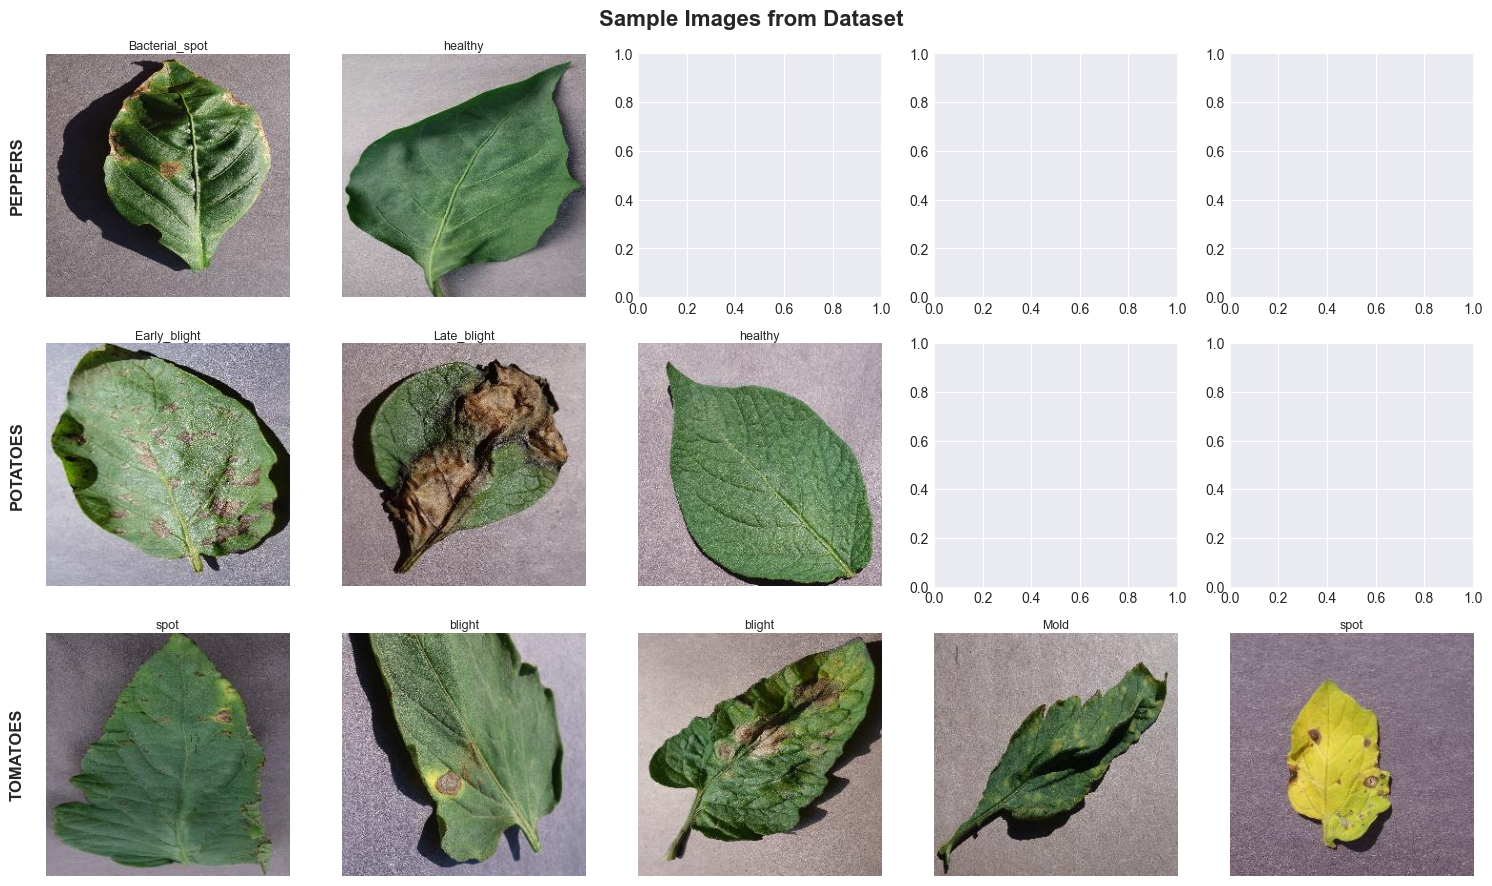

Sample images saved as 'visualizations/sample_images.png'


In [6]:
# Cell 6: Visualize sample images from each plant type
fig, axes = plt.subplots(3, 5, figsize=(15, 9))
fig.suptitle('Sample Images from Dataset', fontsize=16, fontweight='bold', y=0.98)

# Sample from each plant type
sample_classes = [
    pepper_classes,
    potato_classes,
    tomato_classes[:5]  # First 5 tomato classes
]

plant_names = ['PEPPERS', 'POTATOES', 'TOMATOES']

for row_idx, (plant_group, plant_name) in enumerate(zip(sample_classes, plant_names)):
    for col_idx, (cls, _) in enumerate(plant_group):
        if col_idx < 5:  # Only show 5 per row
            class_path = dataset_path / cls
            images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.JPG'))
            
            if images:
                # Pick a random image
                sample_img = random.choice(images)
                img = Image.open(sample_img)
                
                axes[row_idx, col_idx].imshow(img)
                axes[row_idx, col_idx].axis('off')
                
                # Shorten the title
                disease = cls.split('___')[-1] if '___' in cls else cls.split('_')[-1]
                axes[row_idx, col_idx].set_title(disease, fontsize=9, pad=3)
    
    # Add row label
    axes[row_idx, 0].text(-0.15, 0.5, plant_name, transform=axes[row_idx, 0].transAxes,
                          fontsize=12, fontweight='bold', rotation=90, va='center')

plt.tight_layout()
plt.savefig('visualizations/sample_images.png', dpi=150, bbox_inches='tight')
plt.show()

print("Sample images saved as 'visualizations/sample_images.png'")

In [7]:
# Cell 7: Check image properties (dimensions, formats)
print("\n" + "=" * 70)
print("IMAGE PROPERTIES ANALYSIS")
print("=" * 70)

widths = []
heights = []
formats = []

# Sample 1000 random images to check properties
sample_size = min(1000, total_images)
print(f"\nSampling {sample_size} images...\n")

all_images = []
for cls in class_counts.keys():
    class_path = dataset_path / cls
    images = list(class_path.glob('*.jpg')) + list(class_path.glob('*.JPG'))
    all_images.extend(images)

sampled_images = random.sample(all_images, sample_size)

for img_path in sampled_images:
    img = Image.open(img_path)
    widths.append(img.width)
    heights.append(img.height)
    formats.append(img.format)

print(f"Image Dimensions:")
print(f"  Width:  {np.min(widths):>6} - {np.max(widths):>6} px (avg: {np.mean(widths):>6.0f})")
print(f"  Height: {np.min(heights):>6} - {np.max(heights):>6} px (avg: {np.mean(heights):>6.0f})")

# Check if images are uniform
unique_sizes = set(zip(widths, heights))
print(f"\nUnique dimensions: {len(unique_sizes)}")

if len(unique_sizes) == 1:
    print("All images have the same dimensions (uniform)")
else:
    print("Images have varying dimensions (will be resized during training)")
    # Show most common sizes
    size_counter = Counter(zip(widths, heights))
    print("\nMost common sizes:")
    for size, count in size_counter.most_common(5):
        percentage = (count / sample_size) * 100
        print(f"  {size[0]}x{size[1]}: {count} images ({percentage:.1f}%)")

# Format info
format_counter = Counter(formats)
print(f"\nImage Formats:")
for fmt, count in format_counter.items():
    percentage = (count / sample_size) * 100
    print(f"  {fmt}: {count} images ({percentage:.1f}%)")


IMAGE PROPERTIES ANALYSIS

Sampling 1000 images...

Image Dimensions:
  Width:     256 -    256 px (avg:    256)
  Height:    256 -    256 px (avg:    256)

Unique dimensions: 1
All images have the same dimensions (uniform)

Image Formats:
  JPEG: 1000 images (100.0%)


## Summary

This notebook explored the PlantVillage dataset and verified:
- 15 disease classes
- Dataset structure
- Class distribution
- Image properties

### Next Steps:
1. Remove any extra folders before training
2. Use `train_original.ipynb` for baseline training
3. Use `train_augmented.ipynb` for augmented training
4. Compare both models to select the best one